In [1]:
# ==============================================================================
# 🌐 STEP 1: UNIVERSAL ENTERPRISE LIBRARIES IMPORT (LINEAR-FAMILY)
# ==============================================================================
import os
import sys
import warnings
from pathlib import Path

# Scientific Computing & Data Structures
import numpy as np
import pandas as pd

# Visualization Engine
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Ecosystem
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error
)

# Serialization & Production
import joblib

# Global Plotting & Warning Configurations
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print("✅ Universal Linear-Family Enterprise Suite imported successfully.")


✅ Universal Linear-Family Enterprise Suite imported successfully.


In [2]:
# ==============================================================================
# 🌐 STEP 2: ENTERPRISE DATA INGESTION & 3-SECOND RAPID AUDIT
# ==============================================================================
from pathlib import Path
import pandas as pd

def load_and_audit_dataset(file_path):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"❌ File not found at: {path.resolve()}")
        
    try:
        if path.suffix.lower() in ['.xlsx', '.xls']:
            df = pd.read_excel(path)
        else:
            df = pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        print("⚠️ UTF-8 decoding failed. Retrying with 'latin-1' encoding...")
        df = pd.read_csv(path, encoding='latin-1')
        
    print("=" * 70)
    print("📋 3-SECOND STRUCTURAL HEALTH AUDIT REPORT")
    print("=" * 70)
    print(f"File Source               : {path.name}")
    print(f"Total Observations (Rows) : {df.shape[0]:,}")
    print(f"Total Features (Columns)  : {df.shape[1]}")
    print(f"Numerical Columns         : {len(df.select_dtypes(include=['number']).columns)} cols")
    print(f"Categorical/Text Columns  : {len(df.select_dtypes(exclude=['number']).columns)} cols")
    print(f"Missing Value Cells       : {df.isnull().sum().sum():,} nulls ({df.isnull().sum().sum() / (df.shape[0]*df.shape[1]) * 100:.2f}%)")
    print(f"Memory Footprint in RAM   : {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
    print("=" * 70)
    return df

# Ingest Ames Housing Dataset
df = load_and_audit_dataset("data/house_price/train.csv")
display(df.head(5))


📋 3-SECOND STRUCTURAL HEALTH AUDIT REPORT
File Source               : train.csv
Total Observations (Rows) : 1,460
Total Features (Columns)  : 81
Numerical Columns         : 38 cols
Categorical/Text Columns  : 43 cols
Missing Value Cells       : 7,829 nulls (6.62%)
Memory Footprint in RAM   : 1.10 MB


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# ==============================================================================
# 🌐 STEP 3: AUTOMATED 3-BUCKET FEATURE SEGREGATOR
# ==============================================================================
import pandas as pd
import numpy as np

def segregate_features(df, target_col, user_drop_cols=None, cardinality_threshold=0.05):
    if user_drop_cols is None:
        drop_cols = []
    else:
        drop_cols = list(user_drop_cols)
        
    cont_cols = []
    cat_cols = []
    
    candidate_cols = [c for c in df.columns if c != target_col and c not in drop_cols]
    
    for col in candidate_cols:
        col_series = df[col]
        if pd.api.types.is_numeric_dtype(col_series):
            if col_series.nunique() <= 1:
                drop_cols.append(col)
            elif col_series.nunique() <= 2:
                cat_cols.append(col)
            else:
                cont_cols.append(col)
        elif pd.api.types.is_object_dtype(col_series) or pd.api.types.is_string_dtype(col_series):
            unique_ratio = col_series.nunique() / len(df)
            if unique_ratio > cardinality_threshold and col_series.nunique() > 50:
                drop_cols.append(col)
            else:
                cat_cols.append(col)
        else:
            cat_cols.append(col)
            
    print("=" * 70)
    print("🔍 FEATURE SEGREGATION REPORT")
    print("=" * 70)
    print(f"Target Column          : '{target_col}'")
    print(f"Continuous Features    : {len(cont_cols)} cols")
    print(f"Categorical Features   : {len(cat_cols)} cols")
    print(f"Dropped ID / Artifacts : {len(drop_cols)} cols -> {drop_cols}")
    print("=" * 70)
    
    return cont_cols, cat_cols, drop_cols

cont_cols, cat_cols, drop_cols = segregate_features(
    df, 
    target_col='SalePrice', 
    user_drop_cols=['Id']
)


🔍 FEATURE SEGREGATION REPORT
Target Column          : 'SalePrice'
Continuous Features    : 36 cols
Categorical Features   : 43 cols
Dropped ID / Artifacts : 1 cols -> ['Id']


In [4]:
# ==============================================================================
# 🌐 STEP 4: DATA HYGIENE AUDIT (DUPLICATES & MISSINGNESS PROFILER)
# ==============================================================================
import pandas as pd

def audit_and_clean_hygiene(df, drop_duplicates=True):
    print("=" * 70)
    print("🧹 STEP 4: DATA HYGIENE & PURITY REPORT")
    print("=" * 70)
    
    n_dups = df.duplicated().sum()
    if n_dups > 0:
        print(f"⚠️ FOUND {n_dups:,} EXACT DUPLICATE ROWS!")
        if drop_duplicates:
            df = df.drop_duplicates().reset_index(drop=True)
            print(f"✅ Cleaned: {n_dups:,} duplicates removed. New Shape: {df.shape}")
    else:
        print("✅ Zero duplicate rows found. Data integrity is clean.")
    print("-" * 70)

    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0].sort_values(ascending=False)
    
    if len(null_cols) > 0:
        null_report = pd.DataFrame({
            "Missing Count": null_cols,
            "Percentage (%)": (null_cols / len(df) * 100).round(2),
            "Data Type": [df[col].dtype for col in null_cols.index]
        })
        print(f"🚨 FOUND {len(null_cols)} COLUMNS WITH MISSING VALUES (Showing Top 8):")
        print(null_report.head(8).to_string())
    else:
        print("✅ Zero missing values across all features. Dataset is complete.")
    print("=" * 70)
    
    return df

df = audit_and_clean_hygiene(df, drop_duplicates=True)


🧹 STEP 4: DATA HYGIENE & PURITY REPORT
✅ Zero duplicate rows found. Data integrity is clean.
----------------------------------------------------------------------
🚨 FOUND 19 COLUMNS WITH MISSING VALUES (Showing Top 8):
             Missing Count  Percentage (%) Data Type
PoolQC                1453           99.52       str
MiscFeature           1406           96.30       str
Alley                 1369           93.77       str
Fence                 1179           80.75       str
MasVnrType             872           59.73       str
FireplaceQu            690           47.26       str
LotFrontage            259           17.74   float64
GarageType              81            5.55       str


In [5]:
# ==============================================================================
# 🌐 STEP 5: ENTERPRISE TRAIN-TEST SPLITTER (ZERO DATA LEAKAGE + TARGET GUARD)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def perform_zero_leakage_split(df, target_col, drop_cols=None, is_classification=False, apply_log_target=False, test_size=0.20, random_state=42):
    if drop_cols is None:
        drop_cols = []
        
    if df[target_col].isnull().any():
        n_dropped = df[target_col].isnull().sum()
        print(f"⚠️ Target Safety Guard: Dropping {n_dropped:,} rows where target '{target_col}' is NaN!")
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        
    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col]
    
    if not is_classification and apply_log_target:
        skew_before = y.skew()
        y = np.log1p(y)
        skew_after = y.skew()
        print(f"📈 Target Skewness Normalization: {skew_before:.2f} -> {skew_after:.2f} (Bell curve achieved!)")

    stratify_arg = y if is_classification else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify_arg
    )
    
    print("=" * 70)
    print("📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)")
    print("=" * 70)
    print(f"Total Records          : {len(df):,}")
    print(f"Training Matrix (X_tr) : {X_train.shape[0]:,} rows × {X_train.shape[1]} features ({(1-test_size)*100:.0f}%)")
    print(f"Testing Matrix  (X_te) : {X_test.shape[0]:,} rows × {X_test.shape[1]} features ({test_size*100:.0f}%)")
    print(f"Target Missing in y_tr : {y_train.isnull().sum()} nulls (Guaranteed Clean!)")
    print("=" * 70)
    
    return X_train, X_test, y_train, y_test

X_tr, X_te, y_tr, y_te = perform_zero_leakage_split(
    df, 
    target_col='SalePrice', 
    drop_cols=drop_cols, 
    apply_log_target=True
)


📈 Target Skewness Normalization: 1.88 -> 0.12 (Bell curve achieved!)
📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)
Total Records          : 1,460
Training Matrix (X_tr) : 1,168 rows × 79 features (80%)
Testing Matrix  (X_te) : 292 rows × 79 features (20%)
Target Missing in y_tr : 0 nulls (Guaranteed Clean!)


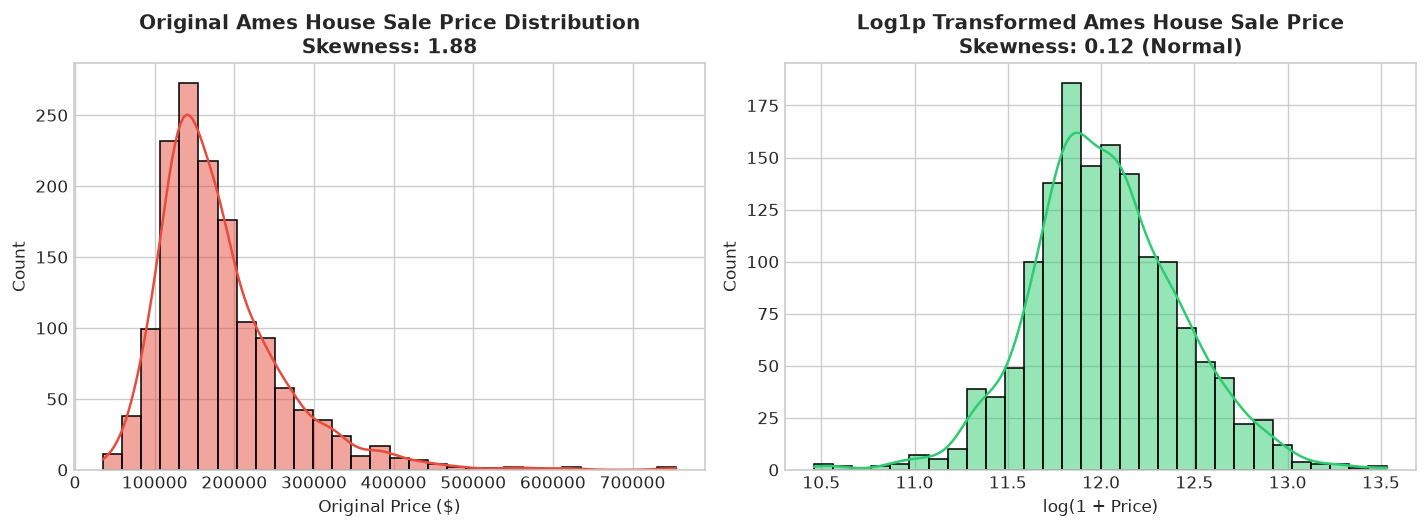

In [6]:
# ==============================================================================
# 🌐 STEP 6: TARGET ANALYSIS & TRANSFORMATION PROFILER
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def profile_target_distribution(y_original, y_transformed, target_name="Price"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    
    sns.histplot(y_original, kde=True, ax=axes[0], color='#e74c3c', bins=30)
    axes[0].set_title(f"Original {target_name} Distribution\nSkewness: {y_original.skew():.2f}", fontweight='bold')
    axes[0].set_xlabel("Original Price ($)")
    
    sns.histplot(y_transformed, kde=True, ax=axes[1], color='#2ecc71', bins=30)
    axes[1].set_title(f"Log1p Transformed {target_name}\nSkewness: {y_transformed.skew():.2f} (Normal)", fontweight='bold')
    axes[1].set_xlabel("log(1 + Price)")
    
    plt.tight_layout()
    plt.show()

profile_target_distribution(df['SalePrice'], np.log1p(df['SalePrice']), target_name="Ames House Sale Price")


In [7]:
# ==============================================================================
# 🌐 STEP 7: UNIVERSAL MASTER COLUMNTRANSFORMER (ZERO DATA LEAKAGE)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def build_universal_preprocessor(continuous_features, categorical_features, cat_impute_value="None"):
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=cat_impute_value)),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, continuous_features),
        ('cat', cat_pipeline, categorical_features)
    ])
    
    return preprocessor

def execute_safe_preprocessing(preprocessor, X_train, X_test, continuous_features, categorical_features):
    X_tr_proc = preprocessor.fit_transform(X_train)
    X_te_proc = preprocessor.transform(X_test)
    
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_encoded_names = list(cat_encoder.get_feature_names_out(categorical_features))
    all_feature_names = continuous_features + cat_encoded_names
    
    print("=" * 70)
    print("⚙️ PREPROCESSING COMPLETE (ZERO DATA LEAKAGE GUARANTEED)")
    print("=" * 70)
    print(f"Continuous Features Processed   : {len(continuous_features)} cols")
    print(f"Categorical Features Processed  : {len(categorical_features)} cols")
    print(f"One-Hot Dummy Features Created  : {len(cat_encoded_names)} cols")
    print(f"Total Model Input Dimensions    : {X_tr_proc.shape[1]} features (Massive Matrix!)")
    print(f"X_train Processed Shape         : {X_tr_proc.shape}")
    print(f"X_test Processed Shape          : {X_te_proc.shape}")
    print("=" * 70)
    
    return X_tr_proc, X_te_proc, all_feature_names

continuous_features, categorical_features = cont_cols, cat_cols
X_train, X_test = X_tr, X_te
preprocessor = build_universal_preprocessor(continuous_features, categorical_features)
X_train_final, X_test_final, all_names = execute_safe_preprocessing(
    preprocessor, X_train, X_test, continuous_features, categorical_features
)


⚙️ PREPROCESSING COMPLETE (ZERO DATA LEAKAGE GUARANTEED)
Continuous Features Processed   : 36 cols
Categorical Features Processed  : 43 cols
One-Hot Dummy Features Created  : 222 cols
Total Model Input Dimensions    : 258 features (Massive Matrix!)
X_train Processed Shape         : (1168, 258)
X_test Processed Shape          : (292, 258)


In [8]:
# ==============================================================================
# 🏆 STEP 8: ELASTICNETCV 2D HYPERPARAMETER TUNING (ALPHA & L1_RATIO GRID)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.model_selection import KFold

# 1. 2D Search Space: l1_ratio x alphas
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
alphas = np.logspace(-4, 0, 50)

# 2. 5-Fold Cross-Validation on Training Data ONLY (Zero Leakage)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
elastic_cv = ElasticNetCV(
    l1_ratio=l1_ratios,
    alphas=alphas,
    cv=kf,
    max_iter=10000,
    tol=1e-3,
    random_state=42
)
elastic_cv.fit(X_train_final, y_tr)

best_alpha = elastic_cv.alpha_
best_l1_ratio = elastic_cv.l1_ratio_

# 3. Fit Best ElasticNet Model
best_elastic = ElasticNet(
    alpha=best_alpha, 
    l1_ratio=best_l1_ratio, 
    max_iter=10000, 
    tol=1e-3, 
    random_state=42
)
best_elastic.fit(X_train_final, y_tr)

# 4. Diagnostic Summary Report
zero_feats = np.sum(best_elastic.coef_ == 0)
total_feats = len(best_elastic.coef_)
active_feats = total_feats - zero_feats

print("=" * 70)
print("🏆 STEP 8: ELASTICNETCV 2D HYPERPARAMETER TUNING REPORT")
print("=" * 70)
print(f"Optimal Alpha (Total Penalty) : {best_alpha:.5f}")
print(f"Optimal L1 Ratio (L1 vs L2)   : {best_l1_ratio:.2f}")
print(f"   • L1 (Lasso Sparsity Part) : {best_l1_ratio * 100:.0f}%")
print(f"   • L2 (Ridge Grouping Part) : {(1 - best_l1_ratio) * 100:.0f}%")
print(f"Total Input Features          : {total_feats} features")
print(f"Active Features Retained      : {active_feats} features (Non-zero)")
print(f"Useless Features Eliminated   : {zero_feats} features ({zero_feats/total_feats*100:.1f}% SPARSITY ACHIEVED!)")
print(f"Model Intercept (log scale)   : {best_elastic.intercept_:.4f}")
print("=" * 70)


🏆 STEP 8: ELASTICNETCV 2D HYPERPARAMETER TUNING REPORT
Optimal Alpha (Total Penalty) : 0.00518
Optimal L1 Ratio (L1 vs L2)   : 0.10
   • L1 (Lasso Sparsity Part) : 10%
   • L2 (Ridge Grouping Part) : 90%
Total Input Features          : 258 features
Active Features Retained      : 126 features (Non-zero)
Useless Features Eliminated   : 132 features (51.2% SPARSITY ACHIEVED!)
Model Intercept (log scale)   : 11.8128


In [9]:
# ==============================================================================
# ⚔️ STEP 9: THE QUAD BATTLE: OLS VS. RIDGE VS. LASSO VS. ELASTICNET
# ==============================================================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

# Optimal alphas from earlier Ames Housing projects
ridge_alpha = 11.51
lasso_alpha = 0.00010

# 1. Fit All 4 Models
ols_m = LinearRegression().fit(X_train_final, y_tr)
ridge_m = Ridge(alpha=ridge_alpha, random_state=42).fit(X_train_final, y_tr)
lasso_m = Lasso(alpha=lasso_alpha, max_iter=10000, tol=1e-3, random_state=42).fit(X_train_final, y_tr)
elastic_m = best_elastic

# 2. Predict on Test Set (Log Scale)
ols_pred_log = ols_m.predict(X_test_final)
ridge_pred_log = ridge_m.predict(X_test_final)
lasso_pred_log = lasso_m.predict(X_test_final)
elastic_pred_log = elastic_m.predict(X_test_final)

# 3. Invert Log Scale back to Real Dollar Valuation (np.expm1)
y_test_real = np.expm1(y_te)
ols_pred_real = np.expm1(ols_pred_log)
ridge_pred_real = np.expm1(ridge_pred_log)
lasso_pred_real = np.expm1(lasso_pred_log)
elastic_pred_real = np.expm1(elastic_pred_log)

# 4. Compile Metrics Table
models = {
    'OLS Linear Regression': (ols_m, ols_pred_log, ols_pred_real),
    'Ridge Regression (L2)': (ridge_m, ridge_pred_log, ridge_pred_real),
    'Lasso Regression (L1)': (lasso_m, lasso_pred_log, lasso_pred_real),
    'ElasticNet (L1 + L2)':  (elastic_m, elastic_pred_log, elastic_pred_real)
}

rows = []
for name, (mod, p_log, p_real) in models.items():
    tr_r2 = r2_score(y_tr, mod.predict(X_train_final))
    te_r2 = r2_score(y_te, p_log)
    rmse = root_mean_squared_error(y_test_real, p_real)
    mae = mean_absolute_error(y_test_real, p_real)
    n_active = np.sum(mod.coef_ != 0)
    total_f = len(mod.coef_)
    
    rows.append({
        'Model Name': name,
        'Train R²': f"{tr_r2*100:.2f}%",
        'Test R²': f"{te_r2*100:.2f}%",
        'Real RMSE': f"${rmse:,.0f}",
        'Real MAE': f"${mae:,.0f}",
        'Active Features': f"{n_active} / {total_f}",
        'Sparsity (%)': f"{(total_f - n_active) / total_f * 100:.1f}%"
    })

quad_df = pd.DataFrame(rows)

print("=" * 90)
print("🏆 THE QUAD BATTLE SHOWDOWN: OLS VS. RIDGE VS. LASSO VS. ELASTICNET")
print("=" * 90)
print(quad_df.to_string(index=False))
print("=" * 90)


🏆 THE QUAD BATTLE SHOWDOWN: OLS VS. RIDGE VS. LASSO VS. ELASTICNET
           Model Name Train R² Test R² Real RMSE Real MAE Active Features Sparsity (%)
OLS Linear Regression   94.49%  83.83%   $25,455  $15,519       258 / 258         0.0%
Ridge Regression (L2)   91.59%  89.66%   $25,380  $16,618       258 / 258         0.0%
Lasso Regression (L1)   93.71%  87.81%   $23,740  $15,220       201 / 258        22.1%
 ElasticNet (L1 + L2)   90.73%  89.43%   $26,028  $16,894       126 / 258        51.2%


⚖️ ELASTICNET FEATURE SELECTION & GROUPING REPORT
Total Features Evaluated     : 258
✅ Surviving Features (Active) : 126 features
❌ Eliminated Noise Features  : 132 features
   Sparsity Percentage        : 51.2%
🔍 TOP 20 INFLUENTIAL DRIVERS SUMMARY TABLE:
             Feature  OLS_Weight  Ridge_Weight  Lasso_Weight  ElasticNet_Weight
Neighborhood_StoneBr    0.123270      0.091182      0.147679           0.093458
Neighborhood_Crawfor    0.083565      0.084629      0.120716           0.088910
         OverallQual    0.055490      0.078098      0.064791           0.084965
Neighborhood_NridgHt    0.044516      0.074656      0.094304           0.084285
 Exterior1st_BrkFace    0.037988      0.072284      0.085706           0.083651
           GrLivArea    0.064655      0.058422      0.042575           0.080138
     Condition2_PosN   -0.807085     -0.073951     -0.696426          -0.065807
      Functional_Typ    0.053823      0.062539      0.054878           0.056886
           PoolQC_Gd   -

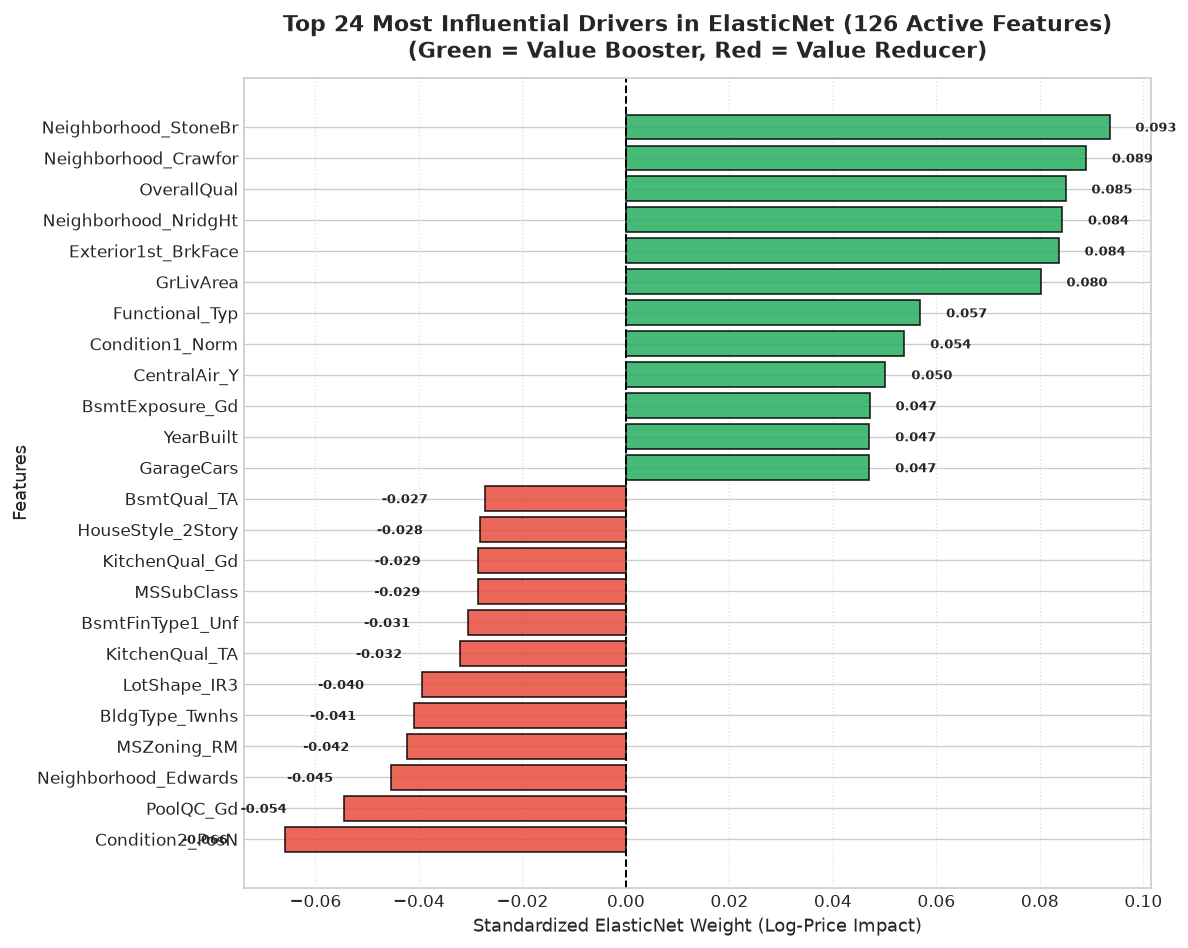

In [10]:
# ==============================================================================
# 📊 STEP 10: ELASTICNET FEATURE IMPORTANCE & GROUPING EFFECT DASHBOARD
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Feature Weights DataFrame Banayein
weights_df = pd.DataFrame({
    'Feature': all_names,
    'OLS_Weight': ols_m.coef_,
    'Ridge_Weight': ridge_m.coef_,
    'Lasso_Weight': lasso_m.coef_,
    'ElasticNet_Weight': best_elastic.coef_
})

# 2. Divide into Survivors vs. Eliminated
survivors = weights_df[weights_df['ElasticNet_Weight'] != 0].sort_values(by='ElasticNet_Weight', ascending=True)
eliminated = weights_df[weights_df['ElasticNet_Weight'] == 0]['Feature'].tolist()

print("=" * 75)
print("⚖️ ELASTICNET FEATURE SELECTION & GROUPING REPORT")
print("=" * 75)
print(f"Total Features Evaluated     : {len(all_names)}")
print(f"✅ Surviving Features (Active) : {len(survivors)} features")
print(f"❌ Eliminated Noise Features  : {len(eliminated)} features")
print(f"   Sparsity Percentage        : {len(eliminated) / len(all_names) * 100:.1f}%")
print("=" * 75)

# 3. Horizontal Bar Chart (Top 12 Positive & Top 12 Negative Drivers)
top_pos = survivors.tail(12)
top_neg = survivors.head(12)
top_drivers = pd.concat([top_neg, top_pos])

plt.figure(figsize=(10, 8))
colors = ['#27ae60' if w > 0 else '#e74c3c' for w in top_drivers['ElasticNet_Weight']]

bars = plt.barh(
    top_drivers['Feature'], 
    top_drivers['ElasticNet_Weight'], 
    color=colors, 
    edgecolor='black', 
    alpha=0.85
)
plt.axvline(0, color='black', linestyle='--', linewidth=1.2)
plt.title(
    f'Top 24 Most Influential Drivers in ElasticNet ({len(survivors)} Active Features)\n(Green = Value Booster, Red = Value Reducer)', 
    fontsize=13, 
    fontweight='bold',
    pad=12
)
plt.xlabel('Standardized ElasticNet Weight (Log-Price Impact)', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.6)

for bar in bars:
    w = bar.get_width()
    offset = 0.005 if w >= 0 else -0.02
    plt.text(
        w + offset, 
        bar.get_y() + 0.25, 
        f'{w:.3f}', 
        fontsize=8, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# 4. Summary Table of Top 20 Most Influential Drivers
print("🔍 TOP 20 INFLUENTIAL DRIVERS SUMMARY TABLE:")
print("=" * 75)
abs_weights = weights_df.copy()
abs_weights['abs_elastic'] = abs_weights['ElasticNet_Weight'].abs()
print(abs_weights.sort_values(by='abs_elastic', ascending=False)[['Feature', 'OLS_Weight', 'Ridge_Weight', 'Lasso_Weight', 'ElasticNet_Weight']].head(20).to_string(index=False))
print("=" * 75)


In [11]:
# ==============================================================================
# 🏭 STEP 11: PRODUCTION PIPELINE SERIALIZATION & LIVE INFERENCE TEST
# ==============================================================================
import joblib
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

# 1. Master End-to-End Production Pipeline banayein
production_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('elasticnet', best_elastic)
])

# 2. Fit strictly on Raw X_tr and Log-transformed Target y_tr
production_pipeline.fit(X_tr, y_tr)

# 3. Model ko Disk par save karein (.joblib)
model_dir = Path('production_models')
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / 'house_price_elasticnet_pipeline.joblib'

joblib.dump(production_pipeline, model_path)

print("=" * 70)
print("🏭 ENTERPRISE PRODUCTION ARTIFACT SUMMARY")
print("=" * 70)
print(f"✅ Full Production Pipeline Saved: {model_path}")
print(f"   Artifact File Size           : {model_path.stat().st_size / 1024:.2f} KB")
print("=" * 70)

# 4. Live Smoke Test: Ek Unseen Ghar par Live Inference
loaded_pipeline = joblib.load(model_path)
sample_house = X_te.iloc[0:1]

# Model se predict karein (Log scale -> Real $ mein invert)
pred_log_price = loaded_pipeline.predict(sample_house)[0]
predicted_dollars = np.expm1(pred_log_price)
actual_dollars = np.expm1(y_te.iloc[0])

print("\n🧪 LIVE REAL-TIME AMES HOUSE VALUATION TEST (1 PROPERTY):")
print("-" * 65)
print(f"   • Overall Quality (1-10) : {sample_house['OverallQual'].values[0]}")
print(f"   • Ground Living Area     : {sample_house['GrLivArea'].values[0]:,} sq ft")
print(f"   • Neighborhood           : {sample_house['Neighborhood'].values[0]}")
print(f"   • Year Built             : {sample_house['YearBuilt'].values[0]}")
print(f"   • Total Basement Area    : {sample_house['TotalBsmtSF'].values[0]:,} sq ft")
print("-" * 65)
print(f"   🎯 Model Predicted Price : ${predicted_dollars:,.0f}")
print(f"   🏷️ Actual Selling Price  : ${actual_dollars:,.0f}")
diff = abs(predicted_dollars - actual_dollars)
print(f"   📊 Valuation Difference  : ${diff:,.0f} ({diff/actual_dollars*100:.1f}%)")
print("=" * 70)


🏭 ENTERPRISE PRODUCTION ARTIFACT SUMMARY
✅ Full Production Pipeline Saved: production_models/house_price_elasticnet_pipeline.joblib
   Artifact File Size           : 20.49 KB

🧪 LIVE REAL-TIME AMES HOUSE VALUATION TEST (1 PROPERTY):
-----------------------------------------------------------------
   • Overall Quality (1-10) : 6
   • Ground Living Area     : 1,068 sq ft
   • Neighborhood           : Sawyer
   • Year Built             : 1963
   • Total Basement Area    : 1,059 sq ft
-----------------------------------------------------------------
   🎯 Model Predicted Price : $156,084
   🏷️ Actual Selling Price  : $154,500
   📊 Valuation Difference  : $1,584 (1.0%)
